<a href="https://colab.research.google.com/github/ritesh23r/HeartDisease_Prediction_model/blob/main/heart_disease_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('heart.csv')

In [3]:
data.shape

(918, 12)

In [4]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

<Axes: >

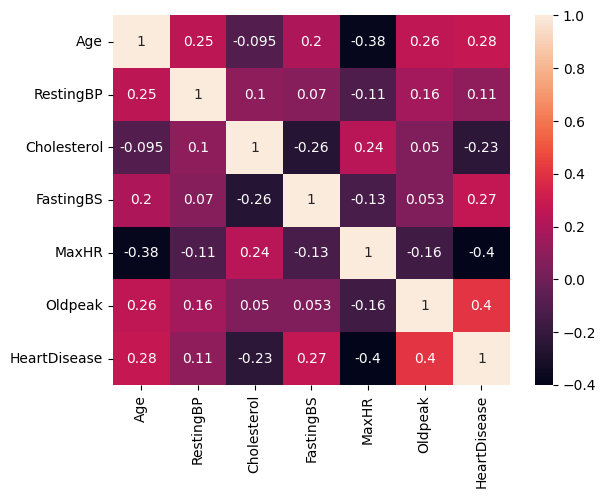

In [10]:
sns.heatmap(data.corr(numeric_only=True),annot = True)

In [11]:
data['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


<Axes: xlabel='ChestPainType', ylabel='count'>

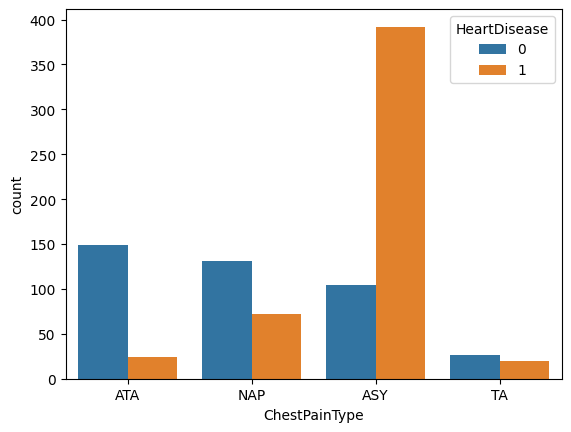

In [12]:
sns.countplot(x='ChestPainType', data=data , hue= 'HeartDisease')

In [13]:
data['Sex'].value_counts()

,count
Sex,
M,725
F,193


<Axes: xlabel='Cholesterol', ylabel='Count'>

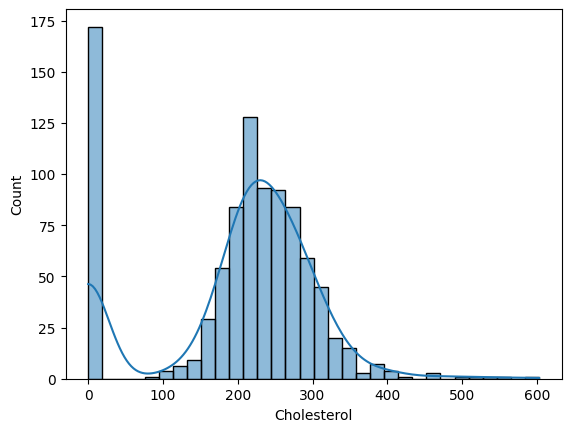

In [14]:
sns.histplot(x='Cholesterol', data=data, kde= True)

<Axes: xlabel='RestingBP', ylabel='Count'>

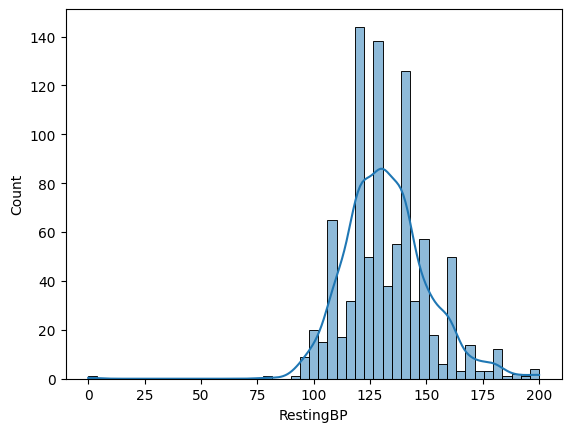

In [15]:
sns.histplot(x='RestingBP', data=data, kde= True)

<Axes: xlabel='Sex', ylabel='count'>

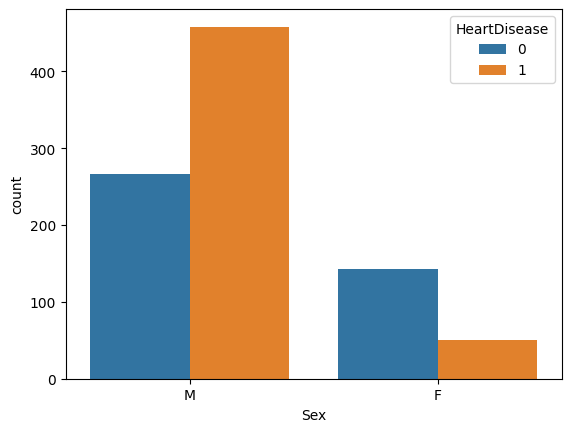

In [16]:
sns.countplot(x='Sex', data=data , hue ='HeartDisease')

In [17]:
data['FastingBS'].value_counts()

,count
FastingBS,
0,704
1,214


<Axes: xlabel='FastingBS', ylabel='count'>

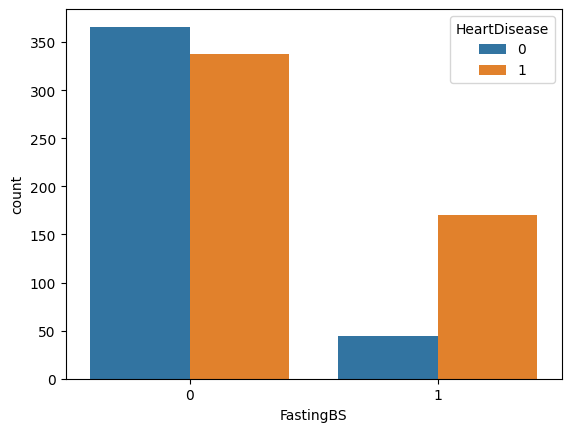

In [18]:
sns.countplot(x='FastingBS', data=data, hue='HeartDisease')

# **Data Cleaning And Preproccesing**

In [19]:
chol_mean = data.loc[data['Cholesterol'] != 0 , 'Cholesterol'].mean()

In [20]:
data['Cholesterol'] = data['Cholesterol'].replace(0,chol_mean)

In [21]:
data.drop(data[data['RestingBP'] == 0].index, inplace = True)

In [22]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [23]:
data_encoded = pd.get_dummies(data, drop_first =True)

In [24]:
data_encoded = data_encoded.astype('int')

In [25]:
data_encoded.rename( columns={'Sex_M':'is_male'}, inplace = True)

In [26]:
data_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,is_male,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [28]:

data_encoded[num_cols]= scaler.fit_transform(data_encoded[num_cols])

In [29]:
data_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,is_male,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.432206,0.414627,0.834288,0,1.383339,-0.726919,0,1,1,0,0,1,0,0,0,1
1,-0.478057,1.526360,-1.210026,0,0.754736,0.283058,1,0,0,1,0,1,0,0,1,0
2,-1.750256,-0.141240,0.721757,0,-1.523953,-0.726919,0,1,1,0,0,0,1,0,0,1
3,-0.584074,0.303453,-0.572350,0,-1.131075,0.283058,1,0,0,0,0,1,0,1,1,0
4,0.052026,0.970493,-0.928698,0,-0.581047,-0.726919,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902124,-1.252973,0.365409,0,-0.188170,0.283058,1,1,0,0,1,1,0,0,1,0
914,1.536257,0.636973,-0.966209,1,0.165420,2.303011,1,1,0,0,0,1,0,0,1,0
915,0.370075,-0.141240,-2.129030,0,-0.856061,0.283058,1,1,0,0,0,1,0,1,1,0
916,0.370075,-0.141240,-0.159736,0,1.461915,-0.726919,1,0,1,0,0,0,0,0,1,0


In [30]:
x = data_encoded.drop('HeartDisease',axis = 1)
y= data_encoded['HeartDisease']

In [31]:
x.columns.tolist()

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'is_male',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test= train_test_split(x,y, test_size = 0.2, random_state = 42)


In [33]:
x

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,is_male,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.432206,0.414627,0.834288,0,1.383339,-0.726919,1,1,0,0,1,0,0,0,1
1,-0.478057,1.526360,-1.210026,0,0.754736,0.283058,0,0,1,0,1,0,0,1,0
2,-1.750256,-0.141240,0.721757,0,-1.523953,-0.726919,1,1,0,0,0,1,0,0,1
3,-0.584074,0.303453,-0.572350,0,-1.131075,0.283058,0,0,0,0,1,0,1,1,0
4,0.052026,0.970493,-0.928698,0,-0.581047,-0.726919,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902124,-1.252973,0.365409,0,-0.188170,0.283058,1,0,0,1,1,0,0,1,0
914,1.536257,0.636973,-0.966209,1,0.165420,2.303011,1,0,0,0,1,0,0,1,0
915,0.370075,-0.141240,-2.129030,0,-0.856061,0.283058,1,0,0,0,1,0,1,1,0
916,0.370075,-0.141240,-0.159736,0,1.461915,-0.726919,0,1,0,0,0,0,0,1,0


In [34]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()


In [35]:
model_LR.fit(X_train,y_train)

LinearRegression()

In [36]:
Y_pred_LR = model_LR.predict(X_test)

In [37]:
from sklearn.metrics import r2_score

In [38]:
r2_score(y_test,Y_pred_LR)

0.5129598138590266

In [39]:
from sklearn.linear_model import LogisticRegression

model_LoR = LogisticRegression()

In [40]:
model_LoR.fit(X_train,y_train)

LogisticRegression()

In [41]:
y_pred_LoR = model_LoR.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [43]:
accuracy_score(y_test,y_pred_LoR)

0.875

In [44]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier()

In [45]:
model_KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [46]:
y_pred_KNN = model_KNN.predict(X_test)

In [47]:
accuracy_score(y_test,y_pred_KNN)

0.8315217391304348

In [48]:
import joblib
joblib.dump(model_LoR,'heart_disease_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']

In [49]:
expected_columns = joblib.load('columns.pkl')

In [50]:
expected_columns

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'is_male',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']